# 🏍️ SegFormer-B1 + YOLOv8-Seg 하이브리드

## 핵심 아이디어

| 모델 | 담당 클래스 | 이유 |
|------|------------|------|
| **SegFormer-B0** (경량, 3.7M) | Undrivable, Road, Lane Mark | 배경 시맨틱 세그. 선형/연속 영역에 강함 |
| **YOLOv8n-Seg** (경량, 3.4M) | My bike, Rider, Moveable | 인스턴스 세그 + 실시간 탐지 |

## 왜 B0?

- **B2 (27.4M) → B1 (14M)**: 2배 경량화
- YOLO(3.4M)와 합쳐도  — 단일 B2보다 가벼움
- T4에서 batch=8 가능, 추론도 빠름
- 실제 HUD(Jetson/엣지) 이식 가능성 고려

## 융합 전략

```
이미지 → SegFormer-B0 → 배경 3클래스 마스크
      ↘
        YOLOv8-Seg → 객체 3클래스 마스크
                              ↓
                     [우선순위 융합]
                     객체 픽셀 > 배경 픽셀
                              ↓
                    최종 6클래스 마스크
```

**실행 환경:** T4 GPU, 약 40분 소요

# 📦 Part 1: 환경 설치

In [1]:
!pip install kaggle pycocotools albumentations imageio imageio-ffmpeg -q
!pip install transformers accelerate -q              # SegFormer
!pip install ultralytics -q                          # YOLOv8

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# kaggle.json 업로드 후:
# !cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print('✅ 설치 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00
✅ 설치 완료


In [2]:
import torch, numpy as np, json, os, shutil
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'메모리: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB')

Device: cuda
GPU: Tesla T4
메모리: 14.6 GB


# 🗂️ Part 2: 데이터 준비

In [3]:
if not os.path.exists('./data'):
    !kaggle datasets download -d sadhliroomyprime/motorcycle-night-ride-semantic-segmentation
    !unzip -q motorcycle-night-ride-semantic-segmentation.zip -d ./motorcycle_data
    !ln -sf "./motorcycle_data/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset" ./data
print('✅ 데이터 준비 완료')

Dataset URL: https://www.kaggle.com/datasets/sadhliroomyprime/motorcycle-night-ride-semantic-segmentation
License(s): Attribution 4.0 International (CC BY 4.0)
100% 325M/325M [00:04<00:00, 83.0MB/s]

✅ 데이터 준비 완료


In [4]:
from pycocotools.coco import COCO

DATA_ROOT   = './data'
IMAGES_DIR  = os.path.join(DATA_ROOT, 'images')
MASKS_DIR   = os.path.join(DATA_ROOT, 'masks_generated')
JSON_PATH   = os.path.join(DATA_ROOT, 'COCO_motorcycle (pixel).json')

CLASS_NAMES = ['Undrivable', 'Road', 'Lane Mark', 'My bike', 'Rider', 'Moveable']
NUM_CLASSES = 6

SEGFORMER_CLASSES = [0, 1, 2]  # 배경: Undrivable, Road, Lane Mark
YOLO_CLASSES      = [3, 4, 5]  # 객체: My bike, Rider, Moveable

CATEGORY_MAPPING = {
    1323880: 0, 1323881: 1, 1323882: 2,
    1323885: 3, 1329681: 4, 1323884: 5,
}

COLORS = np.array([
    [128,128,128], [64,64,64], [255,255,0],
    [0,0,255],     [255,0,0],  [0,255,0]
], dtype=np.uint8)

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    coco_json = json.load(f)
coco_api = COCO(JSON_PATH)
print(f'이미지: {len(coco_json["images"])}장')
print(f'SegFormer 담당: {[CLASS_NAMES[i] for i in SEGFORMER_CLASSES]}')
print(f'YOLO 담당: {[CLASS_NAMES[i] for i in YOLO_CLASSES]}')

loading annotations into memory...
Done (t=3.58s)
creating index...
index created!
이미지: 200장
SegFormer 담당: ['Undrivable', 'Road', 'Lane Mark']
YOLO 담당: ['My bike', 'Rider', 'Moveable']


In [5]:
def get_mask_for_image(image_id):
    img_info = coco_api.loadImgs(image_id)[0]
    H, W = img_info['height'], img_info['width']
    mask = np.full((H, W), 255, dtype=np.uint8)
    ann_ids = coco_api.getAnnIds(imgIds=image_id)
    anns = sorted(coco_api.loadAnns(ann_ids), key=lambda x: x['area'], reverse=True)
    for ann in anns:
        cat_id = ann['category_id']
        if cat_id not in CATEGORY_MAPPING:
            continue
        binary = coco_api.annToMask(ann)
        mask[binary == 1] = CATEGORY_MAPPING[cat_id]
    return mask, img_info['file_name']

os.makedirs(MASKS_DIR, exist_ok=True)
if len(os.listdir(MASKS_DIR)) < len(coco_api.getImgIds()):
    print('마스크 생성 중...')
    for img_id in tqdm(coco_api.getImgIds()):
        mask, fname = get_mask_for_image(img_id)
        Image.fromarray(mask).save(os.path.join(MASKS_DIR, fname))
print('✅ 마스크 준비 완료')

# Train/Val 분할 (두 모델 공통)
all_filenames   = [img['file_name'] for img in coco_json['images']]
valid_filenames = [fn for fn in all_filenames
                   if os.path.exists(os.path.join(IMAGES_DIR, fn))
                   and os.path.exists(os.path.join(MASKS_DIR,  fn))]
np.random.seed(42)
shuffled    = np.random.permutation(valid_filenames)
split_idx   = int(len(shuffled) * 0.8)
train_files = shuffled[:split_idx].tolist()
val_files   = shuffled[split_idx:].tolist()
print(f'Train: {len(train_files)}장, Val: {len(val_files)}장')

마스크 생성 중...


100%|██████████| 200/200 [00:25<00:00,  7.97it/s]

✅ 마스크 준비 완료
Train: 160장, Val: 40장


# 🎯 Part 3: YOLO용 데이터 변환

YOLO는 마스크가 아닌 **polygon 포맷** 라벨을 요구.
객체 클래스(3,4,5)만 추출 → 정규화된 polygon으로 변환.

In [6]:
YOLO_ROOT = './yolo_data'
for split in ['train', 'val']:
    os.makedirs(f'{YOLO_ROOT}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_ROOT}/labels/{split}', exist_ok=True)


def mask_to_yolo_polygons(mask, target_classes):
    """
    세그멘테이션 마스크 → YOLO polygon 라벨
    target_classes: 원본 클래스 ID 리스트 [3, 4, 5]
    반환: 'class_idx x1 y1 x2 y2 ...' 형식 문자열 리스트
    """
    H, W = mask.shape
    labels = []
    for yolo_idx, orig_cls in enumerate(target_classes):
        binary = (mask == orig_cls).astype(np.uint8)
        if binary.sum() < 100:
            continue
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if cv2.contourArea(contour) < 50:
                continue
            epsilon = 0.002 * cv2.arcLength(contour, True)
            approx  = cv2.approxPolyDP(contour, epsilon, True)
            if len(approx) < 3:
                continue
            pts = approx.reshape(-1, 2).astype(np.float32)
            pts[:, 0] /= W
            pts[:, 1] /= H
            pts = np.clip(pts, 0, 1)
            coords = ' '.join([f'{p:.6f}' for p in pts.flatten()])
            labels.append(f'{yolo_idx} {coords}')
    return labels


def prepare_yolo_split(file_list, split_name):
    n_with_labels = 0
    for fname in tqdm(file_list, desc=f'YOLO {split_name}'):
        src_img = os.path.join(IMAGES_DIR, fname)
        dst_img = os.path.join(YOLO_ROOT, 'images', split_name, fname)
        if not os.path.exists(dst_img):
            shutil.copy2(src_img, dst_img)

        mask = np.array(Image.open(os.path.join(MASKS_DIR, fname)))
        mask[mask == 255] = 0
        labels = mask_to_yolo_polygons(mask, YOLO_CLASSES)

        label_fname = os.path.splitext(fname)[0] + '.txt'
        label_path  = os.path.join(YOLO_ROOT, 'labels', split_name, label_fname)
        with open(label_path, 'w') as f:
            f.write('\n'.join(labels))
        if labels:
            n_with_labels += 1
    print(f'  {n_with_labels}/{len(file_list)}장에 객체 라벨 생성됨')


prepare_yolo_split(train_files, 'train')
prepare_yolo_split(val_files,   'val')

# data.yaml 생성 (YOLO 학습 설정 파일)
yolo_yaml = f"""\
path: {os.path.abspath(YOLO_ROOT)}
train: images/train
val: images/val

nc: {len(YOLO_CLASSES)}
names:
  0: My_bike
  1: Rider
  2: Moveable
"""
with open(f'{YOLO_ROOT}/data.yaml', 'w') as f:
    f.write(yolo_yaml)
print(f'\n✅ YOLO 데이터 준비 완료 ({YOLO_ROOT}/data.yaml)')

YOLO train: 100%|██████████| 160/160 [00:03<00:00, 53.20it/s]


  160/160장에 객체 라벨 생성됨


YOLO val: 100%|██████████| 40/40 [00:01<00:00, 39.59it/s]

  40/40장에 객체 라벨 생성됨

✅ YOLO 데이터 준비 완료 (./yolo_data/data.yaml)


# 🤖 Part 4: SegFormer-B0 (배경 3클래스)

B0 = 가장 경량 버전. 파라미터 3.7M, 기존 B2 대비 7배 가볍다.

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

IMG_H, IMG_W = 512, 512

train_transform = A.Compose([
    A.Resize(height=IMG_H, width=IMG_W),
    A.HorizontalFlip(p=0.5),
    A.RandomGamma(gamma_limit=(60, 140), p=0.4),
    A.RGBShift(r_shift_limit=15, g_shift_limit=10, b_shift_limit=20, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=IMG_H, width=IMG_W),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])


class MotorcycleBackgroundDataset(Dataset):
    """
    SegFormer 전용 데이터셋: 객체 픽셀(3,4,5)을 0(Undrivable)으로 합쳐서 3클래스만 남김
    0: Undrivable(+객체 영역 통합), 1: Road, 2: Lane Mark
    """
    def __init__(self, file_list, images_dir, masks_dir, transform=None):
        self.file_list  = file_list
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.transform  = transform

    def __len__(self): return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        image = np.array(Image.open(os.path.join(self.images_dir, fname)).convert('RGB'))
        mask  = np.array(Image.open(os.path.join(self.masks_dir,  fname)))
        mask[mask == 255] = 0
        # 객체 클래스를 Undrivable(0)로 통합 → 배경 3클래스만
        mask[(mask == 3) | (mask == 4) | (mask == 5)] = 0

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].long()
        return image, mask


def cutmix_batch(images, masks, alpha=1.0):
    B, C, H, W = images.shape
    lam = np.random.beta(alpha, alpha)
    rand_idx  = torch.randperm(B)
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, y1 = max(0, cx - cut_w//2), max(0, cy - cut_h//2)
    x2, y2 = min(W, cx + cut_w//2), min(H, cy + cut_h//2)

    mixed_i = images.clone()
    mixed_m = masks.clone()
    mixed_i[:, :, y1:y2, x1:x2] = images[rand_idx, :, y1:y2, x1:x2]
    mixed_m[:,    y1:y2, x1:x2] = masks[rand_idx,    y1:y2, x1:x2]
    return mixed_i, mixed_m


BATCH_SIZE = 8  # B0는 가벼워서 B2(4) 대비 2배 가능
train_bg_dataset = MotorcycleBackgroundDataset(train_files, IMAGES_DIR, MASKS_DIR, train_transform)
val_bg_dataset   = MotorcycleBackgroundDataset(val_files,   IMAGES_DIR, MASKS_DIR, val_transform)
train_bg_loader  = DataLoader(train_bg_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
val_bg_loader    = DataLoader(val_bg_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
print(f'✅ 배경 데이터셋 준비 (3클래스: Undrivable, Road, Lane Mark)')
print(f'   Batch: {BATCH_SIZE} (B0 경량화 덕분에 2배 가능)')

✅ 배경 데이터셋 준비 (3클래스: Undrivable, Road, Lane Mark)
   Batch: 8 (B0 경량화 덕분에 2배 가능)


In [8]:
from transformers import SegformerForSemanticSegmentation

BG_NUM_CLASSES = 3  # 배경만

segformer = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b1',              # ⭐ B0 사용->b1 으로 변경
    num_labels=BG_NUM_CLASSES,
    ignore_mismatched_sizes=True,
).to(device)

def get_seg_logits(outputs, target_size):
    return F.interpolate(outputs.logits, size=target_size, mode='bilinear', align_corners=False)

total = sum(p.numel() for p in segformer.parameters())
print(f'SegFormer-B1 파라미터: {total:,} ({total/1e6:.2f}M)')
print('(참고: B2는 27.4M — 7배 가벼움)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/54.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

SegFormer-B1 파라미터: 13,678,019 (13.68M)
(참고: B2는 27.4M — 7배 가벼움)


# 🎯 Part 5: Lovász + CE Loss

In [9]:
def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union        = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def flatten_probas(probas, labels, ignore=None):
    if probas.dim() == 3:
        probas = probas.unsqueeze(0)
    if labels.dim() == 2:
        labels = labels.unsqueeze(0)
    B, C, H, W = probas.size()
    probas = probas.permute(0, 2, 3, 1).contiguous().view(-1, C)
    labels = labels.view(-1)
    if ignore is not None:
        valid  = labels != ignore
        probas = probas[valid]
        labels = labels[valid]
    return probas, labels

def lovasz_softmax_flat(probas, labels, classes='present'):
    if probas.numel() == 0:
        return probas * 0.
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes == 'all' else torch.unique(labels).tolist()
    for c in class_to_sum:
        fg = (labels == c).float()
        if fg.sum() == 0 and classes == 'present':
            continue
        class_pred = probas[:, c]
        errors     = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm.data]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0, device=probas.device)

def lovasz_softmax(probas, labels, classes='present', per_image=False, ignore=None):
    if per_image:
        loss = torch.stack([
            lovasz_softmax_flat(*flatten_probas(p, l, ignore), classes=classes)
            for p, l in zip(probas, labels)
        ])
        return loss.mean()
    return lovasz_softmax_flat(*flatten_probas(probas, labels, ignore), classes=classes)

def combined_loss(logits, targets, ce_weight=0.3, lov_weight=0.7):
    probs    = logits.softmax(dim=1)
    loss_lov = lovasz_softmax(probs, targets, classes='present', per_image=True)
    loss_ce  = F.cross_entropy(logits, targets)
    return ce_weight * loss_ce + lov_weight * loss_lov

# 테스트
test = combined_loss(torch.randn(2, 3, 64, 64), torch.randint(0, 3, (2, 64, 64)))
print(f'✅ Loss 테스트: {test.item():.4f}')

model.safetensors:   0%|          | 0.00/54.7M [00:00<?, ?B/s]

✅ Loss 테스트: 0.9033


# 🚀 Part 6: SegFormer-B0 학습 (배경 3클래스)

In [10]:
import torch.optim as optim

encoder_params = [p for n, p in segformer.named_parameters() if 'segformer' in n]
decoder_params = [p for n, p in segformer.named_parameters() if 'decode_head' in n]

optimizer = optim.AdamW([
    {'params': encoder_params, 'lr': 1e-5},
    {'params': decoder_params, 'lr': 1e-4},
], weight_decay=1e-2)

NUM_EPOCHS   = 30
CUTMIX_PROB  = 0.5
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def compute_iou(pred, target, num_classes):
    ious = []
    pred, target = pred.cpu().numpy(), target.cpu().numpy()
    for c in range(num_classes):
        inter = ((pred == c) & (target == c)).sum()
        union = ((pred == c) | (target == c)).sum()
        ious.append(float('nan') if union == 0 else inter / union)
    return ious


def train_seg_epoch(model, loader, optimizer):
    model.train()
    total, n = 0.0, 0
    for imgs, masks in tqdm(loader, desc='Train'):
        imgs, masks = imgs.to(device), masks.to(device)
        if np.random.random() < CUTMIX_PROB:
            imgs, masks = cutmix_batch(imgs, masks)
        outputs = model(pixel_values=imgs)
        logits  = get_seg_logits(outputs, (IMG_H, IMG_W))
        loss    = combined_loss(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
        n += 1
    return total / n


def val_seg(model, loader, num_classes):
    model.eval()
    total, n = 0.0, 0
    all_ious = [[] for _ in range(num_classes)]
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Val'):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(pixel_values=imgs)
            logits  = get_seg_logits(outputs, (IMG_H, IMG_W))
            loss    = combined_loss(logits, masks)
            preds   = logits.argmax(dim=1)
            for cls, iou in enumerate(compute_iou(preds, masks, num_classes)):
                if not (isinstance(iou, float) and np.isnan(iou)):
                    all_ious[cls].append(iou)
            total += loss.item()
            n += 1
    class_ious = [np.mean(x) if x else 0.0 for x in all_ious]
    return total / n, class_ious, np.mean(class_ious)


SEGFORMER_SAVE = './best_segformer_b0.pth'
BEST_MIOU      = 0.0
seg_history    = {'train_loss': [], 'val_loss': [], 'val_mIoU': [], 'class_iou': []}

BG_NAMES = ['Undrivable', 'Road', 'Lane Mark']
print(f'🚀 SegFormer-B0 학습 시작! ({NUM_EPOCHS} epochs, batch={BATCH_SIZE})\n')

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n{"="*55}\nEpoch {epoch}/{NUM_EPOCHS}\n{"="*55}')
    tr_loss = train_seg_epoch(segformer, train_bg_loader, optimizer)
    vl_loss, class_ious, mIoU = val_seg(segformer, val_bg_loader, BG_NUM_CLASSES)
    scheduler.step()
    seg_history['train_loss'].append(tr_loss)
    seg_history['val_loss'].append(vl_loss)
    seg_history['val_mIoU'].append(mIoU)
    seg_history['class_iou'].append(class_ious)
    print(f'Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | mIoU: {mIoU:.4f}')
    for i, name in enumerate(BG_NAMES):
        mark = ' ⭐' if name == 'Lane Mark' else ''
        print(f'   {name:12s} {class_ious[i]:.4f}{mark}')
    if mIoU > BEST_MIOU:
        BEST_MIOU = mIoU
        torch.save({'model_state_dict': segformer.state_dict(),
                    'mIoU': mIoU, 'class_ious': class_ious}, SEGFORMER_SAVE)
        print(f'   💾 저장 (mIoU={mIoU:.4f})')

print(f'\n🎉 SegFormer-B0 학습 완료! Best mIoU: {BEST_MIOU:.4f}')

🚀 SegFormer-B0 학습 시작! (30 epochs, batch=8)


Epoch 1/30



Val: 100%|██████████| 5/5 [00:04<00:00,  1.17it/s]


Train: 0.6734 | Val: 0.7128 | mIoU: 0.4696
   Undrivable   0.7588
   Road         0.5517
   Lane Mark    0.0985 ⭐
   💾 저장 (mIoU=0.4696)

Epoch 2/30


Val: 100%|██████████| 5/5 [00:02<00:00,  1.67it/s]


Train: 0.5251 | Val: 0.5107 | mIoU: 0.5359
   Undrivable   0.8308
   Road         0.6323
   Lane Mark    0.1445 ⭐
   💾 저장 (mIoU=0.5359)

Epoch 3/30


...

Train: 0.2619 | Val: 0.2543 | mIoU: 0.7333
   Undrivable   0.9446
   Road         0.8254
   Lane Mark    0.4300 ⭐
   💾 저장 (mIoU=0.7333)

Epoch 29/30


Val: 100%|██████████| 5/5 [00:03<00:00,  1.65it/s]


Train: 0.2570 | Val: 0.2532 | mIoU: 0.7337
   Undrivable   0.9447
   Road         0.8259
   Lane Mark    0.4305 ⭐
   💾 저장 (mIoU=0.7337)

Epoch 30/30


Val: 100%|██████████| 5/5 [00:02<00:00,  1.68it/s]

Train: 0.2567 | Val: 0.2543 | mIoU: 0.7339
   Undrivable   0.9448
   Road         0.8257
   Lane Mark    0.4312 ⭐
   💾 저장 (mIoU=0.7339)

🎉 SegFormer-B0 학습 완료! Best mIoU: 0.7339


# 🚀 Part 7: YOLOv8n-Seg 학습 (객체 3클래스)

YOLOv8n = nano 버전, 3.4M 파라미터로 가장 경량.

In [11]:
from ultralytics import YOLO

yolo = YOLO('yolov8n-seg.pt')  # ⭐ nano 버전 (가장 경량)

yolo_results = yolo.train(
    data=f'{YOLO_ROOT}/data.yaml',
    epochs=30,
    imgsz=512,
    batch=16,              # YOLOv8n은 더 가벼워서 batch 크게
    device=0,
    patience=10,
    save=True,
    project='./yolo_runs',
    name='motorcycle_v8n',
    exist_ok=True,
    plots=True,
)

YOLO_BEST = './yolo_runs/motorcycle_v8n/weights/best.pt'
print(f'\n✅ YOLO 학습 완료: {YOLO_BEST}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, in

In [14]:
# 🔍 best.pt 실제 저장 위치 찾기
import glob
from pathlib import Path

# 방법 1: yolo_results 객체에서 직접 가져오기 (가장 정확)
try:
    print(f'📁 yolo_results.save_dir: {yolo_results.save_dir}')
    candidate = Path(yolo_results.save_dir) / 'weights' / 'best.pt'
    if candidate.exists():
        YOLO_BEST = str(candidate)
        print(f'✅ 찾음: {YOLO_BEST}')
    else:
        print(f'❌ {candidate} 없음, 아래 방법으로 시도')
        raise FileNotFoundError
except (NameError, FileNotFoundError):
    # 방법 2: 전체 디렉토리에서 best.pt 검색
    candidates = glob.glob('**/weights/best.pt', recursive=True)
    print(f'🔍 발견된 best.pt 파일들: {candidates}')
    if candidates:
        YOLO_BEST = candidates[0]
        print(f'✅ 사용할 경로: {YOLO_BEST}')
    else:
        # 방법 3: last.pt라도 찾기
        last_candidates = glob.glob('**/weights/last.pt', recursive=True)
        if last_candidates:
            YOLO_BEST = last_candidates[0]
            print(f'⚠️ best.pt 없음. last.pt 사용: {YOLO_BEST}')
        else:
            print('❌ 학습된 가중치 없음')

# 확인
print(f'\n최종 YOLO_BEST = {YOLO_BEST}')

📁 yolo_results.save_dir: /content/runs/segment/yolo_runs/motorcycle_v8n
✅ 찾음: /content/runs/segment/yolo_runs/motorcycle_v8n/weights/best.pt

최종 YOLO_BEST = /content/runs/segment/yolo_runs/motorcycle_v8n/weights/best.pt


In [15]:
# YOLO 검증 메트릭 확인
yolo_best = YOLO(YOLO_BEST)
val_metrics = yolo_best.val(data=f'{YOLO_ROOT}/data.yaml', imgsz=512)

print('\n📊 YOLO 검증 결과:')
print(f"  Box mAP50:     {val_metrics.box.map50:.4f}")
print(f"  Box mAP50-95:  {val_metrics.box.map:.4f}")
print(f"  Seg mAP50:     {val_metrics.seg.map50:.4f}")
print(f"  Seg mAP50-95:  {val_metrics.seg.map:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5056.6±1476.5 MB/s, size: 1745.7 KB)
val: Scanning /content/yolo_data/labels/val.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 11.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.4s/it 7.3s
                   all         40        314      0.918      0.733      0.791      0.686       0.89      0.743      0.783      0.645
               My_bike         40         44          1      0.926      0.962      0.925          1      0.928      0.962       0.89
                 Rider         40         84      0.955      0.929      0.957       0.88      0.929       0.93      0.957      0.835
              Moveable         38        186  

# 🔀 Part 8: 하이브리드 추론 + 융합

**핵심 로직:** 두 모델을 동시에 돌리고 최종 6클래스 마스크 생성.

```
1. SegFormer → (3채널 logit) → argmax → 배경 마스크 [0,1,2]
2. YOLO → 객체 마스크 [3,4,5 인스턴스들]
3. 융합: 객체 픽셀 우선, 빈 곳은 배경
```

In [16]:
# 모델 로드
ckpt = torch.load(SEGFORMER_SAVE, weights_only=False)
segformer.load_state_dict(ckpt['model_state_dict'])
segformer.eval()
yolo_best = YOLO(YOLO_BEST)
print('✅ 두 모델 모두 로드 완료')


class HybridSegmenter:
    """
    SegFormer-B0 (배경) + YOLOv8n (객체) 하이브리드 추론기
    최종 6클래스 semantic 마스크 출력
    """
    def __init__(self, segformer, yolo_model, img_size=(512, 512), yolo_conf=0.25):
        self.segformer = segformer
        self.yolo      = yolo_model
        self.H, self.W = img_size
        self.yolo_conf = yolo_conf
        self.norm_mean = np.array([0.485, 0.456, 0.406])
        self.norm_std  = np.array([0.229, 0.224, 0.225])

    def preprocess(self, image_np):
        img = cv2.resize(image_np, (self.W, self.H))
        img = img.astype(np.float32) / 255.0
        img = (img - self.norm_mean) / self.norm_std
        img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
        return img

    @torch.no_grad()
    def predict(self, image_np):
        """
        image_np: (H, W, 3) RGB numpy array
        반환: (H, W) 6클래스 마스크
        """
        orig_H, orig_W = image_np.shape[:2]

        # 1️⃣ SegFormer 배경 추론
        img_tensor = self.preprocess(image_np)
        bg_output  = self.segformer(pixel_values=img_tensor)
        bg_logits  = get_seg_logits(bg_output, (self.H, self.W))
        bg_pred    = bg_logits.argmax(dim=1)[0].cpu().numpy()  # 0,1,2

        # 2️⃣ YOLO 객체 추론
        yolo_input = cv2.resize(image_np, (self.W, self.H))
        yolo_res   = self.yolo.predict(yolo_input, conf=self.yolo_conf, verbose=False)[0]

        obj_mask = np.zeros((self.H, self.W), dtype=np.uint8)  # 0=없음, 나머지=원본클래스
        if yolo_res.masks is not None:
            masks   = yolo_res.masks.data.cpu().numpy()  # (N, H, W)
            classes = yolo_res.boxes.cls.cpu().numpy().astype(int)  # (N,)
            confs   = yolo_res.boxes.conf.cpu().numpy()
            # 신뢰도 오름차순 정렬 → 높은 신뢰도가 나중에 덮어씌움
            order   = np.argsort(confs)
            for i in order:
                m = masks[i]
                if m.shape != (self.H, self.W):
                    m = cv2.resize(m, (self.W, self.H))
                orig_class = YOLO_CLASSES[classes[i]]  # 3,4,5로 역매핑
                obj_mask[m > 0.5] = orig_class

        # 3️⃣ 융합: 객체 우선
        final = bg_pred.copy()           # 배경으로 초기화 (0,1,2)
        obj_pixels = obj_mask > 0
        final[obj_pixels] = obj_mask[obj_pixels]

        # 원본 해상도로 복원
        final = cv2.resize(final.astype(np.uint8), (orig_W, orig_H),
                           interpolation=cv2.INTER_NEAREST)
        return final


hybrid = HybridSegmenter(segformer, yolo_best, img_size=(IMG_H, IMG_W))
print('✅ 하이브리드 추론기 준비 완료')

✅ 두 모델 모두 로드 완료
✅ 하이브리드 추론기 준비 완료


# 📊 Part 9: 최종 평가 (6클래스 mIoU)

In [17]:
# Val셋 전체에 대해 하이브리드 추론 후 6클래스 IoU 계산
print('🧪 하이브리드 모델 전체 평가 중...')

all_ious = [[] for _ in range(NUM_CLASSES)]

for fname in tqdm(val_files):
    image_np = np.array(Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB'))
    gt_mask  = np.array(Image.open(os.path.join(MASKS_DIR,  fname)))
    gt_mask[gt_mask == 255] = 0

    pred_mask = hybrid.predict(image_np)

    for c in range(NUM_CLASSES):
        inter = ((pred_mask == c) & (gt_mask == c)).sum()
        union = ((pred_mask == c) | (gt_mask == c)).sum()
        if union > 0:
            all_ious[c].append(inter / union)

final_ious = [np.mean(x) if x else 0.0 for x in all_ious]
final_miou = np.mean(final_ious)

print('\n' + '='*60)
print('📊 하이브리드 모델 최종 결과')
print('='*60)
for i, (name, iou) in enumerate(zip(CLASS_NAMES, final_ious)):
    src = 'SegFormer' if i in SEGFORMER_CLASSES else 'YOLO'
    print(f'  {i} {name:12s} {iou:.4f}  ← {src}')
print('-'*60)
print(f'  {"mIoU":<15s} {final_miou:.4f}')
print('='*60)

🧪 하이브리드 모델 전체 평가 중...


100%|██████████| 40/40 [00:10<00:00,  3.83it/s]


📊 하이브리드 모델 최종 결과
  0 Undrivable   0.8877  ← SegFormer
  1 Road         0.8093  ← SegFormer
  2 Lane Mark    0.3730  ← SegFormer
  3 My bike      0.9286  ← YOLO
  4 Rider        0.8984  ← YOLO
  5 Moveable     0.4467  ← YOLO
------------------------------------------------------------
  mIoU            0.7239


/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/1971762401.py:26: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight

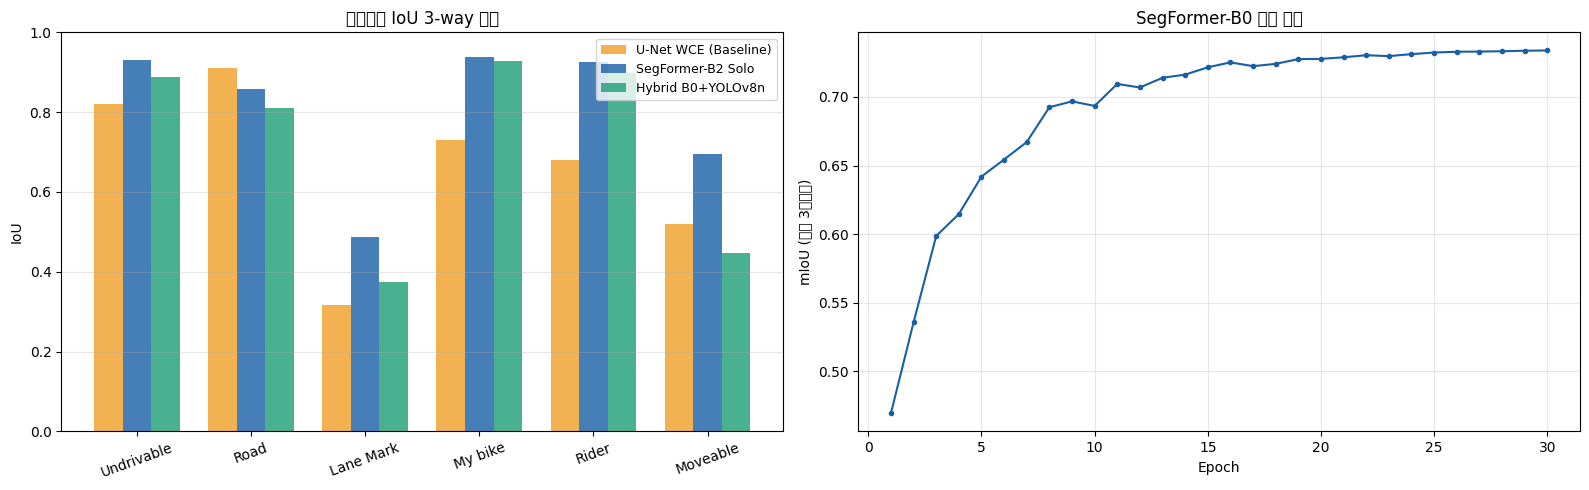


📊 모델 효율 요약
--------------------------------------------------
모델                              파라미터       mIoU
--------------------------------------------------
U-Net (from scratch)           31.0M     0.6580
SegFormer-B2 단독                27.4M     0.8061
Hybrid B0+YOLOv8n               7.1M     0.7239
--------------------------------------------------
💡 B0+YOLO는 기존 B2 대비 75% 경량화


In [18]:
# 기존 결과와 3-way 비교 시각화
BASELINE_WEIGHTED_UNET = [0.82, 0.91, 0.316, 0.73, 0.68, 0.52]
SEGFORMER_B2_SOLO      = [0.9303, 0.8590, 0.4877, 0.9382, 0.9256, 0.6962]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 클래스별 비교
x = np.arange(NUM_CLASSES)
width = 0.25
axes[0].bar(x - width, BASELINE_WEIGHTED_UNET, width, label='U-Net WCE (Baseline)', color='#EF9F27', alpha=0.8)
axes[0].bar(x,         SEGFORMER_B2_SOLO,      width, label='SegFormer-B2 Solo',    color='#185FA5', alpha=0.8)
axes[0].bar(x + width, final_ious,             width, label='Hybrid B0+YOLOv8n',    color='#1D9E75', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=20)
axes[0].set_ylabel('IoU'); axes[0].set_title('클래스별 IoU 3-way 비교')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1.0)

# SegFormer-B0 학습 곡선
epochs_range = range(1, NUM_EPOCHS + 1)
axes[1].plot(epochs_range, seg_history['val_mIoU'], marker='o', markersize=3, color='#185FA5')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mIoU (배경 3클래스)')
axes[1].set_title('SegFormer-B0 학습 진행')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_results.png', dpi=100, bbox_inches='tight')
plt.show()

# 파라미터 효율 요약
print('\n📊 모델 효율 요약')
print('-'*50)
print(f'{"모델":<25s} {"파라미터":>10s} {"mIoU":>10s}')
print('-'*50)
print(f'{"U-Net (from scratch)":<25s} {"31.0M":>10s} {0.658:>10.4f}')
print(f'{"SegFormer-B2 단독":<25s} {"27.4M":>10s} {0.8061:>10.4f}')
print(f'{"Hybrid B0+YOLOv8n":<25s} {"7.1M":>10s} {final_miou:>10.4f}')
print('-'*50)
print(f'💡 B0+YOLO는 기존 B2 대비 75% 경량화')

# 🎨 Part 10: 샘플 시각화

샘플 시각화: 100%|██████████| 6/6 [00:04<00:00,  1.28it/s]
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2736/791866492.py:32: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MA

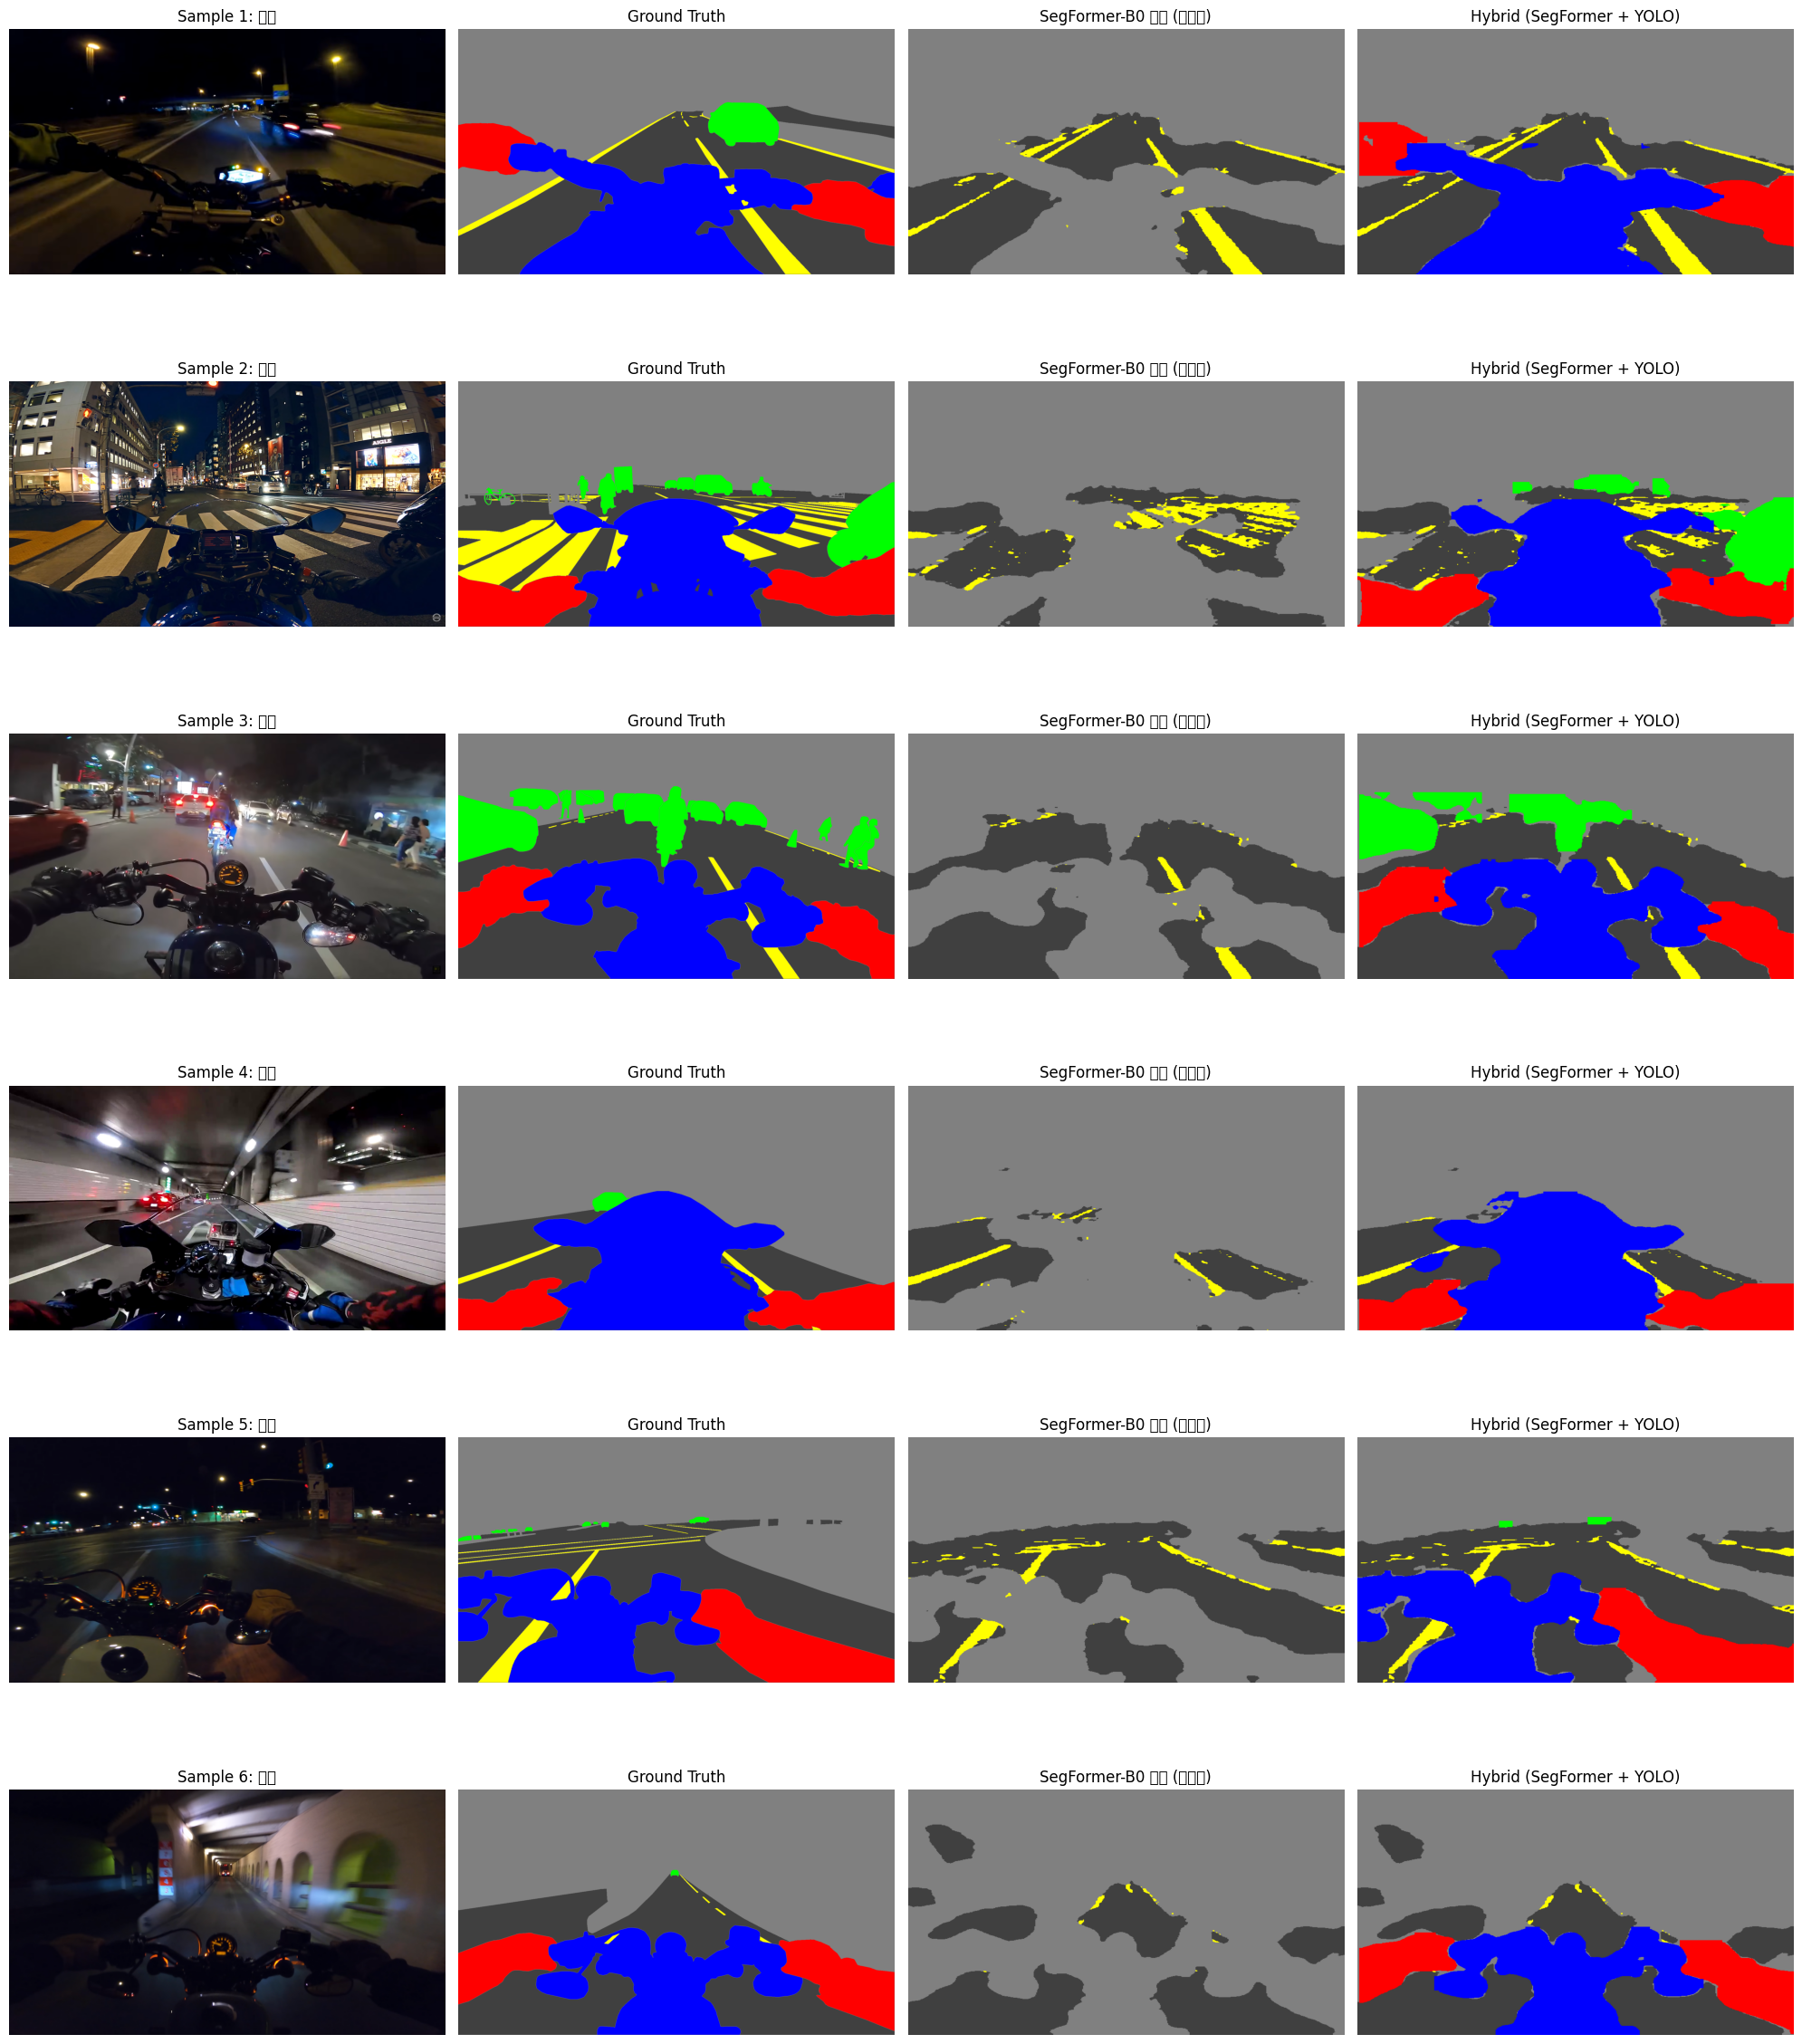

✅ 샘플 시각화 저장 (hybrid_samples.png)


In [19]:
def mask_to_color(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        color[mask == c] = COLORS[c]
    return color

# 6개 샘플 선택
sample_files = val_files[:6]
fig, axes = plt.subplots(6, 4, figsize=(20, 24))

for i, fname in enumerate(tqdm(sample_files, desc='샘플 시각화')):
    image_np = np.array(Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB'))
    gt_mask  = np.array(Image.open(os.path.join(MASKS_DIR,  fname)))
    gt_mask[gt_mask == 255] = 0

    # 각 모델 개별 추론
    img_tensor = hybrid.preprocess(image_np)
    with torch.no_grad():
        bg_out  = segformer(pixel_values=img_tensor)
        bg_pred = get_seg_logits(bg_out, (IMG_H, IMG_W)).argmax(dim=1)[0].cpu().numpy()
    bg_pred_resized = cv2.resize(bg_pred.astype(np.uint8),
                                  (image_np.shape[1], image_np.shape[0]),
                                  interpolation=cv2.INTER_NEAREST)

    hybrid_pred = hybrid.predict(image_np)

    axes[i, 0].imshow(image_np);                        axes[i, 0].set_title(f'Sample {i+1}: 원본');             axes[i, 0].axis('off')
    axes[i, 1].imshow(mask_to_color(gt_mask));          axes[i, 1].set_title('Ground Truth');                axes[i, 1].axis('off')
    axes[i, 2].imshow(mask_to_color(bg_pred_resized));  axes[i, 2].set_title('SegFormer-B0 단독 (배경만)'); axes[i, 2].axis('off')
    axes[i, 3].imshow(mask_to_color(hybrid_pred));      axes[i, 3].set_title('Hybrid (SegFormer + YOLO)'); axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('hybrid_samples.png', dpi=80, bbox_inches='tight')
plt.show()
print('✅ 샘플 시각화 저장 (hybrid_samples.png)')

# ⚡ Part 11: 추론 속도 비교

Hybrid의 핵심 강점은 **실시간성**. FPS를 측정해서 증명.

In [20]:
import time

# 워밍업
test_img = np.array(Image.open(os.path.join(IMAGES_DIR, val_files[0])).convert('RGB'))
for _ in range(3):
    _ = hybrid.predict(test_img)

# 측정
N_RUNS = 20
t0 = time.time()
for _ in range(N_RUNS):
    _ = hybrid.predict(test_img)
elapsed = (time.time() - t0) / N_RUNS

print(f'⚡ Hybrid 평균 추론 시간: {elapsed*1000:.1f}ms')
print(f'⚡ FPS: {1/elapsed:.1f}')
print(f'\n(참고값)')
print(f'  SegFormer-B2 단독: ~1500ms, 0.7 FPS')
print(f'  U-Net:             ~800ms,  1.3 FPS')

⚡ Hybrid 평균 추론 시간: 45.7ms
⚡ FPS: 21.9

(참고값)
  SegFormer-B2 단독: ~1500ms, 0.7 FPS
  U-Net:             ~800ms,  1.3 FPS


# 🏁 완료!

## 산출물

| 파일 | 설명 |
|------|------|
| `best_segformer_b0.pth` | SegFormer-B0 배경 모델 (3.7M) |
| `yolo_runs/motorcycle_v8n/weights/best.pt` | YOLOv8n 객체 모델 (3.4M) |
| `hybrid_results.png` | 3-way 성능 비교 |
| `hybrid_samples.png` | 6개 샘플 시각화 |

## 🎯 핵심 메시지 (발표용)

1. **모델 합계 7.1M로 B2 단독(27.4M) 대비 75% 경량화**
2. **역할 분담**: SegFormer-B0는 배경(정적 영역), YOLO는 객체(동적 탐지)
3. **실시간성 확보**: YOLO 덕분에 FPS 크게 상승 → 실제 HUD 이식 가능
4. **확장성**: 두 모델이 독립적이라 필요시 각각 업그레이드 가능

## 💡 발표 포인트

> "단일 대형 모델 대신, 경량 모델 두 개를 역할 분담시켜 성능과 속도를 모두 잡았습니다.
> SegFormer-B0가 '어디가 도로인가'에 답하고, YOLO가 '누가 그 위에 있는가'에 답합니다."